In [1]:
from langchain_google_genai import GoogleGenerativeAI
# If python-dotenv is not installed in this environment, install it from the terminal:
# pip install python-dotenv
from dotenv import load_dotenv
import os

load_dotenv()

# Check if GOOGLE_API_KEY is set
api_key = os.environ.get("GOOGLE_API_KEY")

if api_key:
    print("✓ API key is set correctly.")
else:
    print("✗ GOOGLE_API_KEY not found. Please:")
    print("  1. Create a .env file in the project root with: GOOGLE_API_KEY=your_key_here")
    print("  2. Get your key from: https://aistudio.google.com/app/apikey")
    print("  3. Restart the kernel (Ctrl+Shift+F10)")
    raise ValueError("GOOGLE_API_KEY is not set in .env file")

✓ API key is set correctly.


In [2]:
llm = GoogleGenerativeAI(
    model="gemini-3.5-flash",  # or "gemini-3.5-turbo"
    temperature=0.7,)

In [4]:
llm.invoke("What aspect is the best to learn Google ai studio agents, n8n or" \
" langGraph ")

'To determine which of these three tools is the "best" to learn, you have to look at **your coding background** and **what you want to build**. \n\nThese three tools represent three completely different philosophies of building AI agents: **Google AI Studio** (Ecosystem & Speed), **n8n** (Visual Workflows & Integrations), and **LangGraph** (Code-First & Complex Logic).\n\nHere is the breakdown of the best aspect of each tool to help you decide where to focus.\n\n---\n\n### 1. Google AI Studio (Agents)\n*The Best Aspect:* **Rapid Prototyping & Gemini’s Multimodal Power**\n\nGoogle AI Studio is a web-based prototyping environment. It is designed to let you quickly build, test, and deploy agents using Google’s Gemini models.\n\n*   **Why it’s the best:**\n    *   **Unmatched Speed:** You can build a functioning agent with tool-calling capabilities (like Google Search or custom APIs) in under 5 minutes without writing code.\n    *   **Gemini\'s 2-Million Token Context:** If your agent need

### Pydantic Schema

In [5]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The LinkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post content")


demo_obj = graph_schema(
    topic="The importance of data privacy in the digital age",
    post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy.",
    curated_post="In the digital age, data privacy is more important than ever. With the"
)
print(demo_obj)

topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy." curated_post='In the digital age, data privacy is more important than ever. With the'


In [6]:
def create_post(state: graph_schema) -> graph_schema:
    
    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}").content

    # Update the state with the generated post
    state['post'] = post

    return state


def curate_post(state: graph_schema) -> graph_schema:

    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the post from the state
    post = state['post']

    # Passing the post to the LLM to curate it
    curated_post = llm.invoke(f"Curate the following LinkedIn post with GenZ tone: {post}").content


    # Update the state with the curated post
    state['curated_post'] = curated_post

    return state

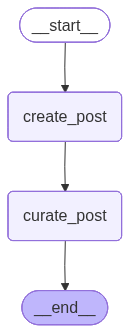

In [7]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()



from IPython.display import Image, display

# You could see the errors with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [9]:
pydantic_graph.invoke(
    {"topic": "The importance of data privacy in the digital age",
     "post": "",
     "curated_post": ""}
)

AttributeError: 'str' object has no attribute 'content'